In [21]:
import warnings
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_csv("insurance (1).csv")
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [23]:
dtype = df.dtypes
n_unique = df.nunique()
pd.DataFrame({"dtypes" : dtype , "nuique" : n_unique}).T


,age,sex,bmi,children,smoker,region,charges
dtypes,int64,object,float64,int64,object,object,float64
nuique,47,2,548,6,2,4,1337


In [24]:
cat_cols = ['sex' , 'smoker' , 'region' ,'children']
df[cat_cols] =df[cat_cols].astype("category")



In [25]:
pd.DataFrame(df.dtypes).T

,age,sex,bmi,children,smoker,region,charges
0,int64,category,float64,category,category,category,float64


In [26]:
pd.DataFrame(df.isnull().sum()).T

,age,sex,bmi,children,smoker,region,charges
0,0,0,0,0,0,0,0


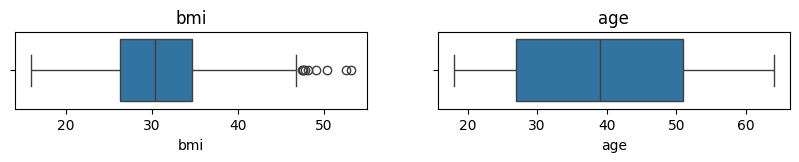

In [27]:
num_cols = ['bmi' , 'age']
plt.figure(figsize=(10,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2 , i+1)
    plt.title(f"{col}")
    sns.boxplot(df[col] , orient="h")
plt.show()

In [28]:
Q1 = df.bmi.quantile(0.25)
Q3 = df.bmi.quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df.bmi > upper].bmi.values
df.bmi.replace(outliers , upper , inplace=True)



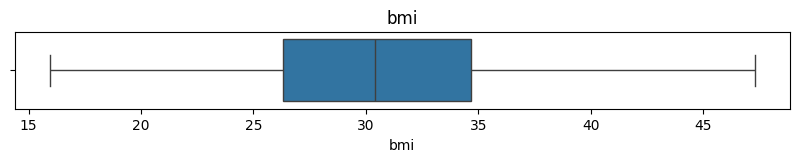

In [29]:
plt.figure(figsize=(10,1))
plt.title("bmi")
sns.boxplot(df.bmi , orient="h")
plt.show()

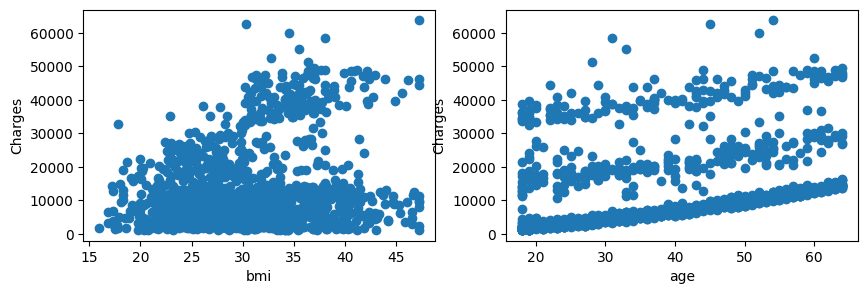

In [30]:
plt.figure(figsize=(10, 3))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    plt.xlabel(f"{col}")
    plt.ylabel(f"Charges")
    plt.scatter(df[col], df.charges)
plt.show()

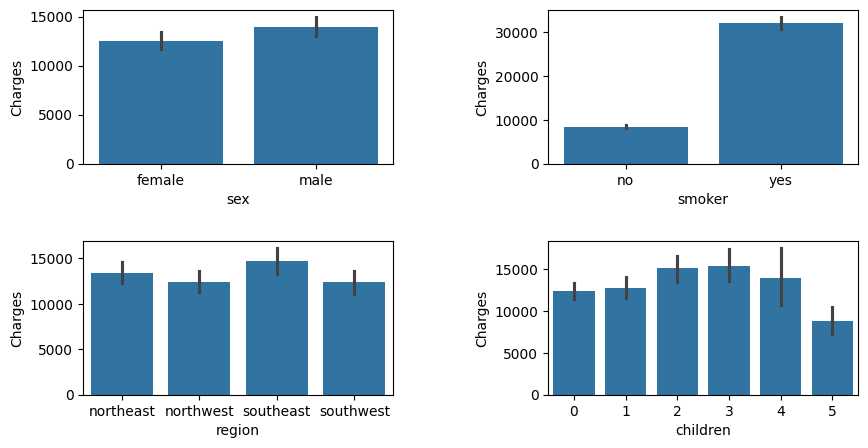

In [34]:
plt.figure(figsize=(10 , 5))
for i , col in enumerate(cat_cols):
    plt.subplot(2,2 , i+1)
    plt.xlabel(f"{col}")
    plt.ylabel("Charges")
    sns.barplot(x = col , y = "charges", data = df)
plt.subplots_adjust(hspace= 0.5 , wspace=.5)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

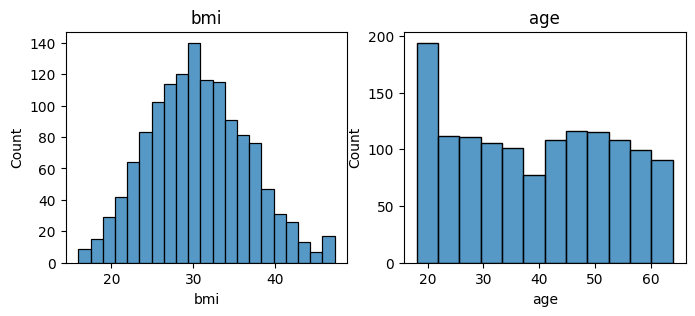

In [35]:
plt.figure(figsize=(8 , 3))
for i , col in enumerate(num_cols):
    plt.subplot(1,2 , i+1 )
    plt.title(f"{col}")
    sns.histplot(x = col , data=df)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

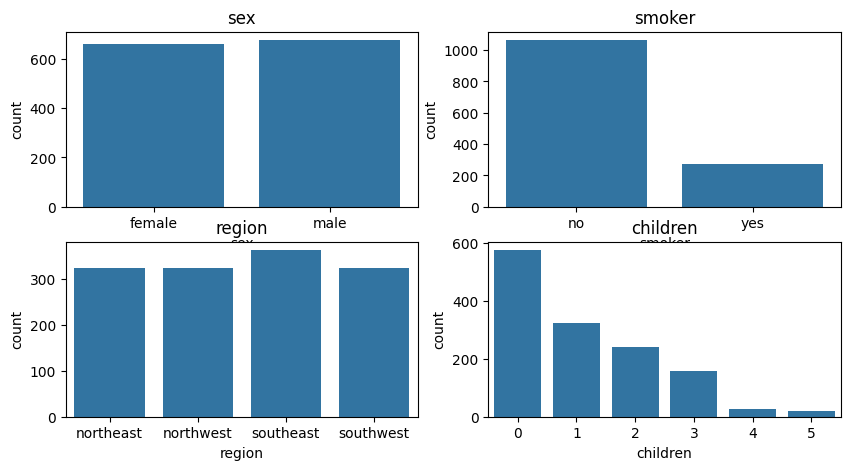

In [39]:
plt.figure(figsize=(10 , 5))
for i , col in enumerate(cat_cols):
    plt.subplot(2,2 , i+1 )
    plt.title(f"{col}")
    sns.countplot(x = col , data=df)
plt.show

In [ ]:
df.duplicated().sum()
df.drop_duplicates(keep="first" , inplace=True)
df.duplicated().sum()

np.int64(0)

In [45]:
x= df.iloc[:,:-1]
y = df.iloc[:,-1:]
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500
